# Four-way K-fold Hybrid Comparison

This notebook creates the exact plot requested for presentation:

1. LSTM/MCLDNN k-fold
2. Normal attention k-fold
3. Differential attention k-fold
4. Automated SNR-aware hybrid k-fold

Important:

- Existing k-fold checkpoints are reused if already present.
- Missing k-fold checkpoints are trained automatically.
- The hybrid is automated using fold-validation accuracy per SNR.
- No alpha blending.
- No monotonic smoothing.
- Final plot is mean ? std across folds.

Output folder:

```text
experiments/5class_fourway_kfold_hybrid/
```

In [1]:
# CELL 1: Setup repo and paths
import os
import sys
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

import pandas as pd
from IPython.display import Image, display, FileLink

os.environ['KERAS_BACKEND'] = 'tensorflow'

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = Path('/kaggle/working/amr-5-class')

DATASET_CANDIDATES = [
    Path('/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'),
    Path('/kaggle/input/rml201610a-dict/RML2016.10a_dict.dat'),
    Path('/kaggle/input/radioml2016-10a/RML2016.10a_dict.pkl'),

]

def find_attached_repo():
    input_root = Path('/kaggle/input')
    if not input_root.exists():
        return None
    for root in input_root.glob('**'):
        if (root / 'src' / 'train.py').exists() and (root / 'configs').exists():
            return root
    return None

if (Path.cwd() / 'src' / 'train.py').exists():
    WORK_DIR = Path.cwd()
    print('Using current repo:', WORK_DIR)
elif (WORK_DIR / 'src' / 'train.py').exists():
    print('Using existing repo:', WORK_DIR)
else:
    attached = find_attached_repo()
    if attached is not None:
        print('Copying attached repo from:', attached)
        if WORK_DIR.exists():
            shutil.rmtree(WORK_DIR)
        shutil.copytree(attached, WORK_DIR)
    else:
        print('Cloning repo from GitHub...')
        subprocess.run(['git', 'clone', REPO_URL, str(WORK_DIR)], check=True)

os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

DATASET = next((p for p in DATASET_CANDIDATES if p.exists()), None)
assert DATASET is not None, 'Dataset not found. Set DATASET manually in this cell.'

BASELINE_KFOLD_DIR = Path('experiments/5class_baseline_kfold/kfold')
NORMAL_KFOLD_DIR = Path('experiments/5class_attention_kfold/kfold')
DIFF_KFOLD_DIR = Path('experiments/5class_diffattention_kfold/kfold')
OUT_DIR = Path('experiments/5class_fourway_kfold_hybrid')

print('Working dir:', Path.cwd())
print('Dataset    :', DATASET)
print('Dataset OK :', DATASET.exists())

Cloning repo from GitHub...


Cloning into '/kaggle/working/amr-5-class'...


Working dir: /kaggle/working/amr-5-class
Dataset    : /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Dataset OK : True


Updating files: 100% (1111/1111), done.


In [2]:
# CELL 2: Check required source files
required = [
    'src/train_kfold.py',
    'src/evaluate_fourway_kfold_hybrid.py',
    'src/models/mcldnn.py',
    'src/models/mcldnn_attention.py',
    'src/models/mcldnn_diffattention.py',
    'configs/exp_5class_baseline_kfold.yaml',
    'configs/exp_5class_attention_kfold.yaml',
    'configs/exp_5class_diffattention_kfold.yaml',
]

for f in required:
    print(('OK      ' if Path(f).exists() else 'MISSING ') + f)
    assert Path(f).exists(), f'Missing required file: {f}'

def kfold_ready(kfold_dir, n_folds=5):
    return all((kfold_dir / f'fold_{i}/best_model.weights.h5').exists() for i in range(n_folds))

print('LSTM baseline k-fold ready:', kfold_ready(BASELINE_KFOLD_DIR))
print('Normal attention k-fold ready:', kfold_ready(NORMAL_KFOLD_DIR))
print('Diff attention k-fold ready:', kfold_ready(DIFF_KFOLD_DIR))

OK      src/train_kfold.py
OK      src/evaluate_fourway_kfold_hybrid.py
OK      src/models/mcldnn.py
OK      src/models/mcldnn_attention.py
OK      src/models/mcldnn_diffattention.py
OK      configs/exp_5class_baseline_kfold.yaml
OK      configs/exp_5class_attention_kfold.yaml
OK      configs/exp_5class_diffattention_kfold.yaml
LSTM baseline k-fold ready: True
Normal attention k-fold ready: True
Diff attention k-fold ready: False


In [3]:
# CELL 3: Train missing k-fold models
# Existing complete k-fold folders are reused. Only missing fold sets are trained.

def run_stream(cmd):
    print('Running:', ' '.join(map(str, cmd)))
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in process.stdout:
        print(line, end='', flush=True)
    rc = process.wait()
    if rc != 0:
        raise subprocess.CalledProcessError(rc, process.args)

jobs = [
    ('lstm_baseline_kfold', BASELINE_KFOLD_DIR, 'configs/exp_5class_baseline_kfold.yaml'),
    ('normal_attention_kfold', NORMAL_KFOLD_DIR, 'configs/exp_5class_attention_kfold.yaml'),
    ('diff_attention_kfold', DIFF_KFOLD_DIR, 'configs/exp_5class_diffattention_kfold.yaml'),
]

for name, kfold_dir, cfg in jobs:
    if kfold_ready(kfold_dir):
        print(f'{name}: all 5 fold checkpoints found, skipping training.')
    else:
        print(f'{name}: missing fold checkpoint(s), training now...')
        run_stream([sys.executable, '-u', 'src/train_kfold.py', '--config', cfg, '--datasetpath', str(DATASET)])
        assert kfold_ready(kfold_dir), f'K-fold training finished but checkpoints are missing: {kfold_dir}'

lstm_baseline_kfold: all 5 fold checkpoints found, skipping training.
normal_attention_kfold: all 5 fold checkpoints found, skipping training.
diff_attention_kfold: missing fold checkpoint(s), training now...
Running: /usr/bin/python3 -u src/train_kfold.py --config configs/exp_5class_diffattention_kfold.yaml --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
[seed] All seeds fixed to 2016  (Python, NumPy, TensorFlow 2.20.0)

  K-Fold CV : 5class_diffattention_kfold
  Model     : mcldnn_diffattention
  Folds     : 5
  Dropout   : 0.5  L2 Dense: 0.001  L2 LSTM: 0.0001
  LR        : 0.0005    ES patience: 20
  Classes   : ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
  Output    : experiments/5class_diffattention_kfold/kfold

[kfold] Loading raw dataset ...
[kfold] 5 classes × 20 SNRs × 1000 = 100000 samples
[kfold] Test set   : 20,000 samples (20%)
[kfold] Train+Val  : 80,000 samples per fold rotation
[kfold] Per fold   : ~16,000 val  /  ~64,000 train

In [4]:
# CELL 4: Run four-way k-fold hybrid evaluation
if OUT_DIR.exists():
    print('Removing old four-way outputs:', OUT_DIR)
    shutil.rmtree(OUT_DIR)

cmd = [
    sys.executable, '-u', 'src/evaluate_fourway_kfold_hybrid.py',
    '--datasetpath', str(DATASET),
    '--baseline-kfold-dir', str(BASELINE_KFOLD_DIR),
    '--normal-kfold-dir', str(NORMAL_KFOLD_DIR),
    '--diff-kfold-dir', str(DIFF_KFOLD_DIR),
    '--output-dir', str(OUT_DIR),
    '--n-folds', '5',
    '--low-snr-max', '2',
    '--min-val-delta', '0.0',
]
run_stream(cmd)

assert (OUT_DIR / 'results/fourway_kfold_mean_std_acc_per_snr.csv').exists()
assert (OUT_DIR / 'figures/fourway_kfold_lstm_normal_diff_hybrid_acc_vs_snr.png').exists()
print('Four-way k-fold hybrid evaluation complete.')

Running: /usr/bin/python3 -u src/evaluate_fourway_kfold_hybrid.py --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat --baseline-kfold-dir experiments/5class_baseline_kfold/kfold --normal-kfold-dir experiments/5class_attention_kfold/kfold --diff-kfold-dir experiments/5class_diffattention_kfold/kfold --output-dir experiments/5class_fourway_kfold_hybrid --n-folds 5 --low-snr-max 2 --min-val-delta 0.0
[fourway-kfold] Loaded LSTM k-fold curve from CSV: experiments/5class_baseline_kfold/kfold/test/acc_per_snr.csv

  Experiment : fourway_kfold_hybrid
  Curves     : LSTM, normal-att, diff-att, automated hybrid
  Hybrid     : validation-selected per fold/SNR; no alpha
  Low SNR max: 2 dB
  Output dir : experiments/5class_fourway_kfold_hybrid


[fourway-kfold] Fold 1/5
I0000 00:00:1783948756.853055    9547 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus

In [5]:
# CELL 5: Display result tables
summary = pd.read_csv(OUT_DIR / 'results/fourway_kfold_mean_std_acc_per_snr.csv')
fold_rows = pd.read_csv(OUT_DIR / 'results/fourway_kfold_fold_acc_per_snr.csv')
metadata = pd.read_json(OUT_DIR / 'results/fourway_kfold_metadata.json', typ='series')

print('Mean ? std across folds per SNR')
display(summary)

print('Per-fold values and hybrid route choices')
display(fold_rows)

print('Metadata')
display(metadata)

Mean ? std across folds per SNR


,snr,n_folds,lstm_kfold_accuracy_mean,lstm_kfold_accuracy_std,normal_attention_kfold_accuracy_mean,normal_attention_kfold_accuracy_std,diff_attention_kfold_accuracy_mean,diff_attention_kfold_accuracy_std,automated_hybrid_kfold_accuracy_mean,automated_hybrid_kfold_accuracy_std,hybrid_minus_normal_mean,hybrid_minus_lstm_mean,hybrid_minus_diff_mean
0,-20,5,0.308,0.000000e+00,0.2868,0.018433,0.3428,0.011703,0.3428,0.011703,0.0560,0.0348,0.0000
1,-18,5,0.313,0.000000e+00,0.2770,0.019940,0.3202,0.008998,0.3202,0.008998,0.0432,0.0072,0.0000
2,-16,5,0.329,0.000000e+00,0.2918,0.009064,0.3384,0.011638,0.3384,0.011638,0.0466,0.0094,0.0000
3,-14,5,0.345,0.000000e+00,0.3004,0.025168,0.3498,0.006524,0.3498,0.006524,0.0494,0.0048,0.0000
4,-12,5,0.298,0.000000e+00,0.2870,0.018708,0.3258,0.003250,0.3258,0.003250,0.0388,0.0278,0.0000
5,-10,5,0.298,0.000000e+00,0.2746,0.023406,0.3246,0.013366,0.3246,0.013366,0.0500,0.0266,0.0000
6,-8,5,0.300,0.000000e+00,0.2656,0.011534,0.3080,0.003633,0.3080,0.003633,0.0424,0.0080,0.0000
7,-6,5,0.336,0.000000e+00,0.2946,0.019479,0.3290,0.012345,0.3290,0.012345,0.0344,-0.0070,0.0000
8,-4,5,0.464,0.000000e+00,0.4236,0.020762,0.4272,0.008134,0.4332,0.015992,0.0096,-0.0308,0.0060
9,-2,5,0.589,0.000000e+00,0.5910,0.016211,0.6148,0.014274,0.6180,0.011437,0.0270,0.0290,0.0032


Per-fold values and hybrid route choices


,fold,snr,selected_model_for_hybrid,lstm_kfold_accuracy,normal_attention_kfold_accuracy,diff_attention_kfold_accuracy,automated_hybrid_kfold_accuracy,normal_val_accuracy,diff_val_accuracy,diff_minus_normal_val
0,0,-20,diff_attention,0.308,0.281,0.356,0.356,0.28000,0.34375,0.06375
1,0,-18,diff_attention,0.313,0.281,0.329,0.329,0.27875,0.35125,0.07250
2,0,-16,diff_attention,0.329,0.289,0.346,0.346,0.28000,0.32250,0.04250
3,0,-14,diff_attention,0.345,0.289,0.350,0.350,0.27500,0.33375,0.05875
4,0,-12,diff_attention,0.298,0.280,0.322,0.322,0.26250,0.33375,0.07125
...,...,...,...,...,...,...,...,...,...,...
95,4,10,normal_attention,0.942,0.889,0.900,0.889,0.88375,0.90375,0.02000
96,4,12,normal_attention,0.934,0.907,0.919,0.907,0.89500,0.91125,0.01625
97,4,14,normal_attention,0.937,0.908,0.901,0.908,0.89750,0.89750,0.00000
98,4,16,normal_attention,0.928,0.882,0.898,0.882,0.89250,0.91000,0.01750


Metadata


method                                              fourway_kfold_hybrid_comparison
n_folds                                                                           5
low_snr_max                                                                       2
min_val_delta                                                                   0.0
hybrid_rule                       For each fold and SNR <= 2 dB, choose diff-att...
alpha_used                                                                    False
monotonic_smoothing_used                                                      False
baseline_kfold_dir                          experiments/5class_baseline_kfold/kfold
baseline_kfold_csv                experiments/5class_baseline_kfold/kfold/test/a...
baseline_curve_loaded_from_csv                                                 True
normal_kfold_dir                           experiments/5class_attention_kfold/kfold
diff_kfold_dir                         experiments/5class_diffattention_kfol

experiments/5class_fourway_kfold_hybrid/figures/fourway_kfold_lstm_normal_diff_hybrid_acc_vs_snr.png


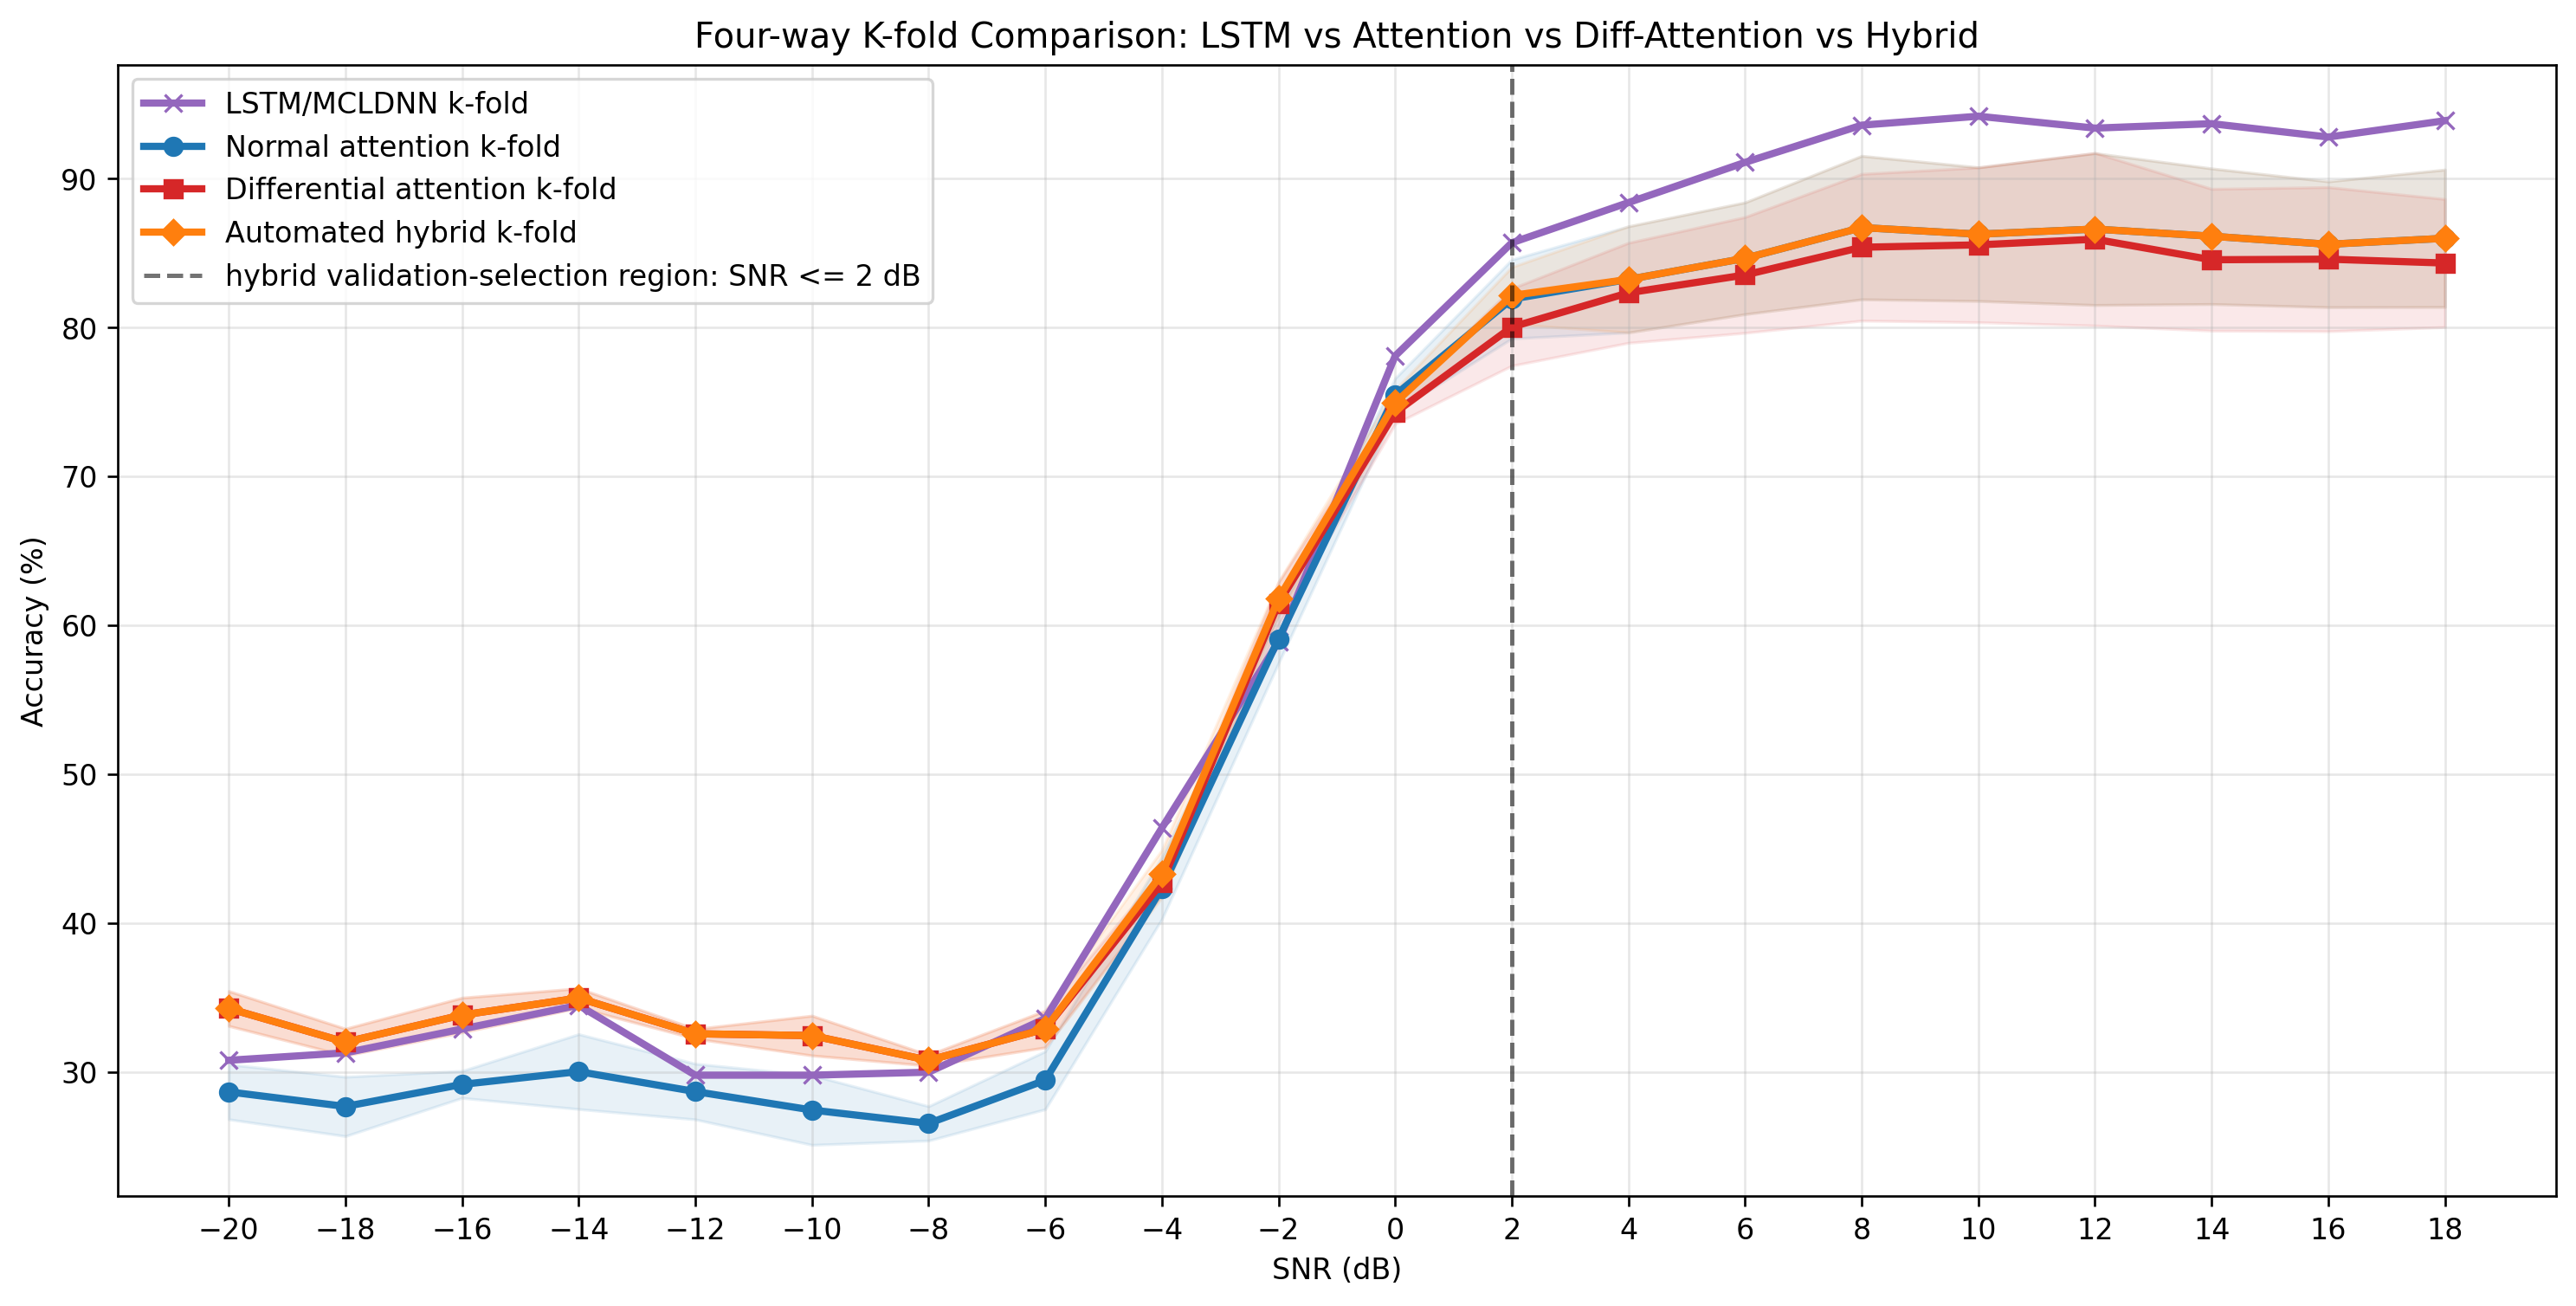

experiments/5class_fourway_kfold_hybrid/figures/automated_hybrid_kfold_delta_vs_models.png


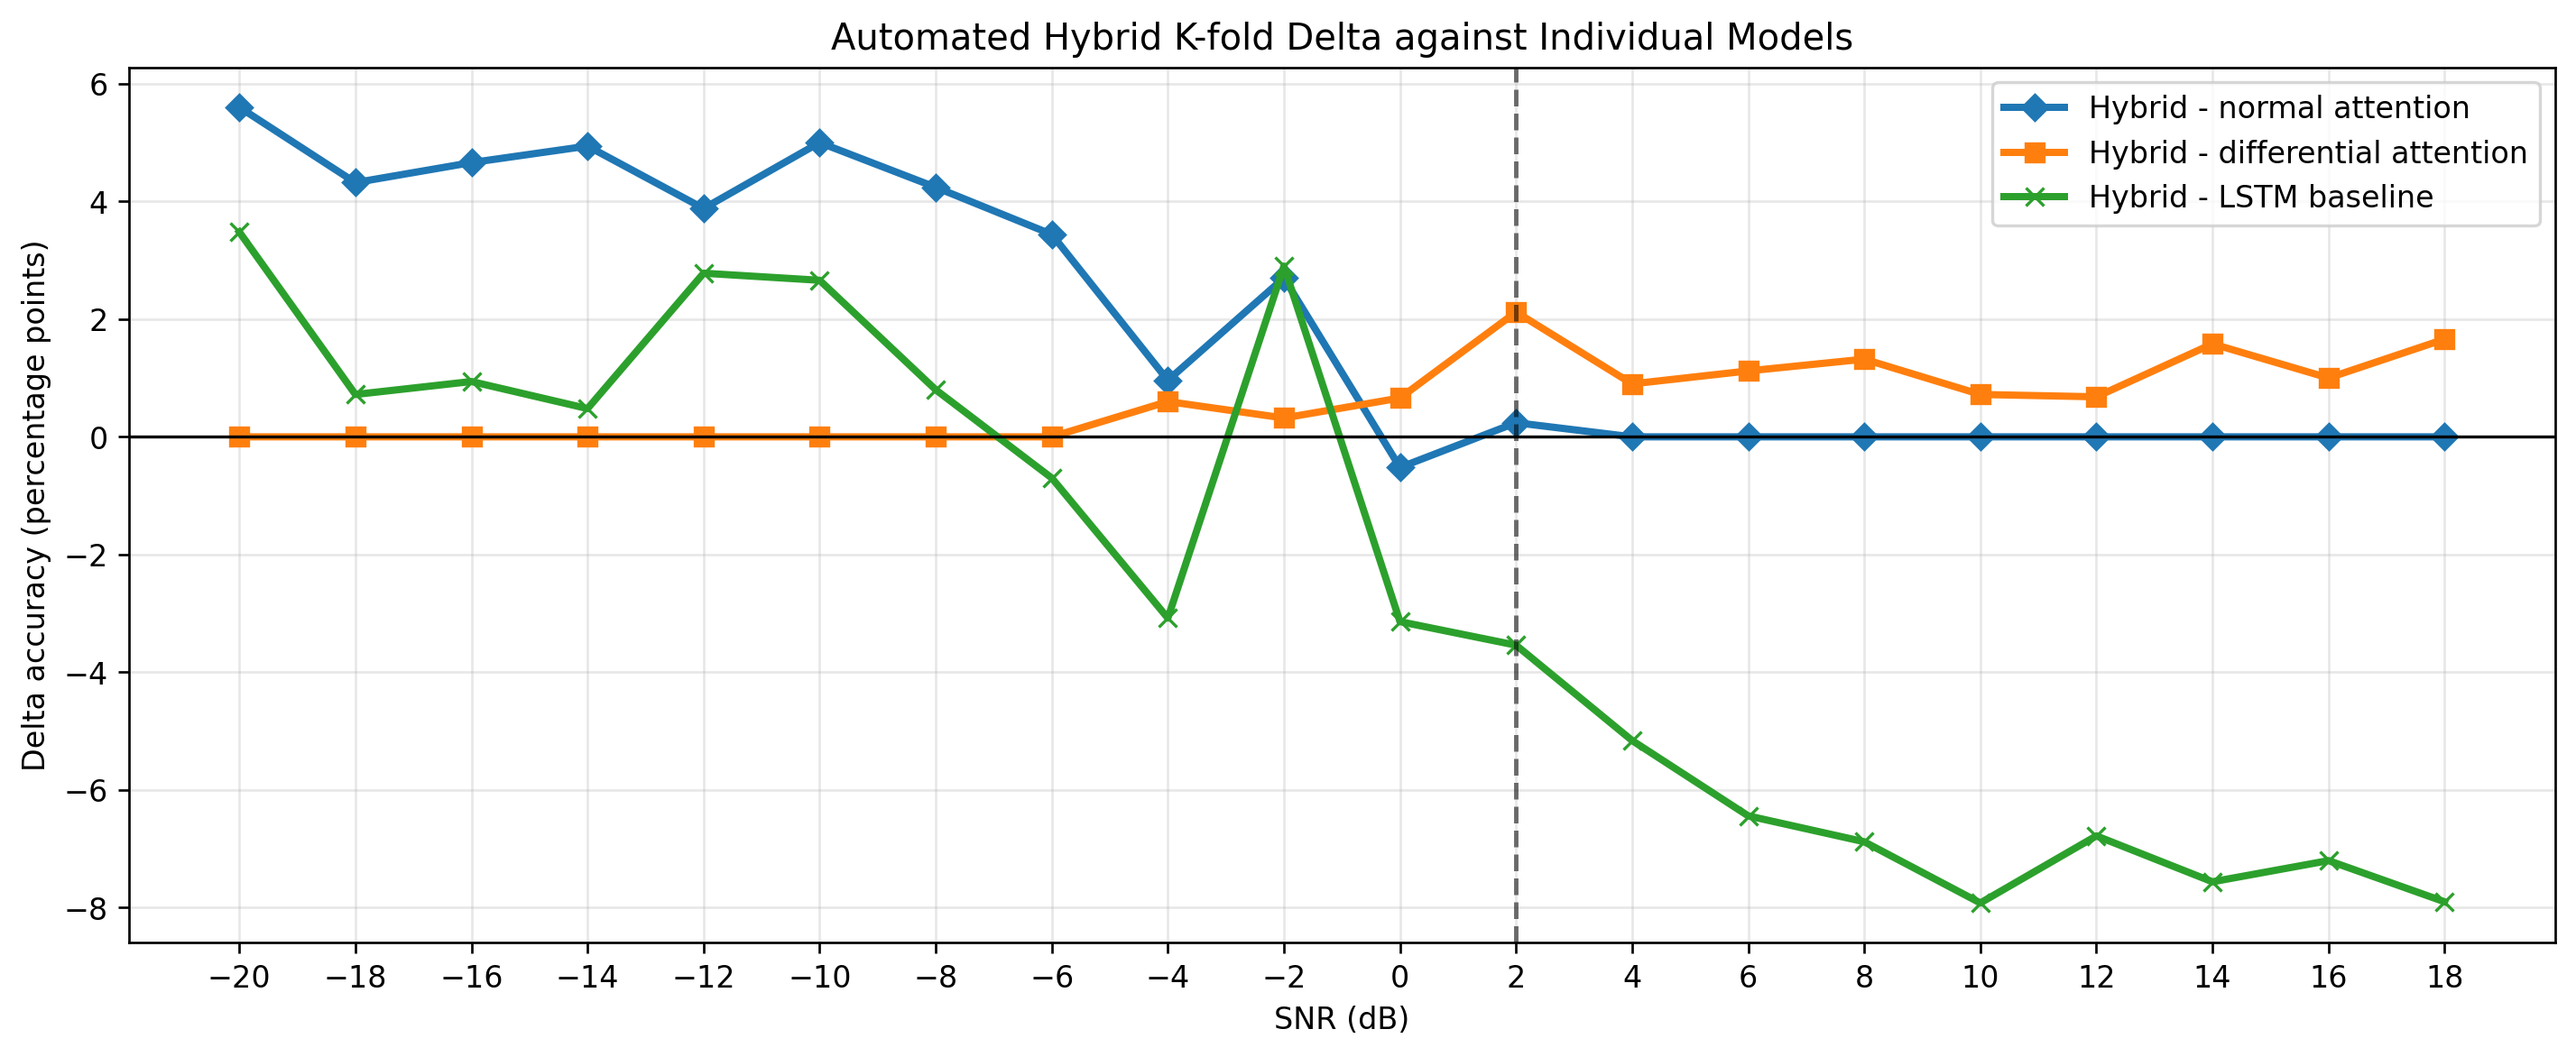

In [6]:
# CELL 6: Display final four-way plots
figs = [
    OUT_DIR / 'figures/fourway_kfold_lstm_normal_diff_hybrid_acc_vs_snr.png',
    OUT_DIR / 'figures/automated_hybrid_kfold_delta_vs_models.png',
]

for fig in figs:
    print(fig)
    display(Image(filename=str(fig)))

In [14]:
# CELL 7: Create repo-ready zip for four-way + differential-attention k-fold results
from datetime import datetime
from pathlib import Path
from IPython.display import FileLink, display
import shutil
import os

stamp = datetime.now().strftime('%Y%m%d_%H%M')

zip_name = f'fourway_and_diffattention_kfold_repo_ready_{stamp}'
staging_dir = Path('/kaggle/working') / f'{zip_name}_staging'
zip_base = Path('/kaggle/working') / zip_name
zip_path = Path('/kaggle/working') / f'{zip_name}.zip'

# Clean old files if rerun
if staging_dir.exists():
    shutil.rmtree(staging_dir)
if zip_path.exists():
    zip_path.unlink()

folders_to_zip = [
    # 'experiments/5class_fourway_kfold_hybrid',
    'experiments/5class_diffattention_kfold',
]

for rel_folder in folders_to_zip:
    src = WORK_DIR / rel_folder
    dst = staging_dir / rel_folder

    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f'Included: {rel_folder}')
    else:
        print(f'WARNING: Missing, not included: {rel_folder}')

created_zip = shutil.make_archive(
    str(zip_base),
    'zip',
    root_dir=str(staging_dir),
)

print('\nCreated repo-ready zip:')
print(created_zip)

print('\nZip size:', os.path.getsize(created_zip) / (1024 * 1024), 'MB')

print('\nExtract this at repo root. It will create/update:')
for rel_folder in folders_to_zip:
    print(f'  {rel_folder}/')

print('\nDownload link:')
display(FileLink(created_zip))

Included: experiments/5class_diffattention_kfold

Created repo-ready zip:
/kaggle/working/fourway_and_diffattention_kfold_repo_ready_20260713_1329.zip

Zip size: 14.1730375289917 MB

Extract this at repo root. It will create/update:
  experiments/5class_diffattention_kfold/

Download link:


/kaggle/working/fourway_and_diffattention_kfold_repo_ready_20260713_1329.zip

In [15]:
import shutil
from pathlib import Path

src = Path('/kaggle/working/fourway_and_diffattention_kfold_repo_ready_20260713_1329.zip')
dst = Path('/kaggle/working/results.zip')

shutil.copy2(src, dst)

print('Final output file saved as:')
print(dst)
print('Size MB:', dst.stat().st_size / (1024 * 1024))

Final output file saved as:
/kaggle/working/results.zip
Size MB: 14.1730375289917
